In [131]:
import random
def generate_random_graph(n=6):
    nodes = [chr(65+i) for i in range(n)]
    positions = {node: (random.randint(0, 100), random.randint(0, 100)) for node in nodes}
    graph = {node: [] for node in nodes}

    for u in nodes:
        for v in nodes:
            if u != v and random.random() < 0.3:
                if random.random() < 0.5:
                    time = random.randint(1, 10)
                    cost = random.randint(400, 500)
                    mode = "air"
                    graph[u].append((v, time, cost, mode))
                if random.random() < 0.5:
                    time = random.randint(20, 30)
                    cost = random.randint(50, 200)
                    mode = "water"
                    graph[u].append((v, time, cost, mode))
                if random.random() < 0.5:
                    time = random.randint(10, 20)
                    cost = random.randint(200, 400)
                    mode = "road"
                    graph[u].append((v, time, cost, mode))
    res = {'id': 'G01_thucte',
            'size_group': 'medium',
            'tradeoff': False,
            'nodes': nodes,
            'start': nodes[0],
            'goal': nodes[-1],
            'Tmax': random.randint(20, 50),
            'P': random.randint(1, 15),
            'positions': positions,
            'graph': graph}
    return res

In [132]:
import time
import matplotlib.pyplot as plt
import numpy as np
from data.experiment_graphs_20_static import EXPERIMENT_GRAPHS_20, MANH_GRAPHS_1
from algorithms.brute_force import brute_force
from algorithms.backtracking import backtracking
from algorithms.branch_and_bound import branch_and_bound
from algorithms.A_star import A_star
from collections import defaultdict


def run_benchmark(graphs_to_test):
    algorithms = [
        ("Brute Force", brute_force),
        ("Backtracking", backtracking),
        ("Branch and Bound", branch_and_bound),
        ("A*", A_star)
    ]

    # Lưu trữ kết quả: { "Algorithm Name": [list of execution times], ... }
    stats = {name: {"times": [], "costs": [], "optimal_cost": []} for name, _ in algorithms}
      # Tạo đồ thị 20 đỉnh
    for case_idx, case in enumerate(graphs_to_test):
        graph = case["graph"]
        start = case["start"]
        target = case["goal"]
        deadline = case["Tmax"]
        penalty = case["P"]

        # Tìm đáp án tối ưu từ Brute Force làm chuẩn (Ground Truth)
        # Lưu ý: Chạy Brute Force trước để lấy cost chuẩn cho case này
        # optimal_cost = None
        
        for name, algo in algorithms:
            if name == "Brute Force" and len(case["nodes"]) >15:
                # Bỏ qua Brute Force cho đồ thị lớn hơn 15 đỉnh
                stats[name]["times"].append(float('inf'))  # Đánh dấu là không thực thi được
                stats[name]["costs"].append(float('inf'))  # Đánh dấu là không thực thi được
                continue
            start_time = time.perf_counter()
            result = algo(graph, start, target, deadline, penalty)
            exec_time = time.perf_counter() - start_time

            cost = result["total_cost"] if result else float('inf')
            
            stats[name]["times"].append(exec_time)
            stats[name]["costs"].append(cost)

    return stats

def analyze_and_plot(stats):
    names = list(stats.keys())
    avg_times = []
    accuracies = []

    # Lấy dữ liệu Backtracking làm chuẩn
    bf_costs = stats["Backtracking"]["costs"]
    total_cases = len(bf_costs)

    print(f"{'Thuật toán':<20} | {'Thời gian TB (s)':<18} | {'Độ chính xác (%)'}")
    print("-" * 60)

    for name in names:
        # 1. Tính thời gian trung bình
        avg_time = np.mean(stats[name]["times"])
        avg_times.append(avg_time)

        # 2. Tính độ chính xác (so sánh cost với Backtracking)
        correct_count = 0
        for i in range(total_cases):
            if stats[name]["costs"][i] == stats["Backtracking"]["costs"][i]:
                correct_count += 1
        
        accuracy = (correct_count / total_cases) * 100
        accuracies.append(accuracy)

        print(f"{name:<20} | {avg_time:<18.6f} | {accuracy:.2f}%")

    # --- VẼ BIỂU ĐỒ ---
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Biểu đồ cột cho Thời gian
    color = 'tab:blue'
    ax1.set_xlabel('Thuật toán')
    ax1.set_ylabel('Thời gian chạy TB (giây)', color=color)
    bars = ax1.bar(names, avg_times, color=color, alpha=0.6, label='Thời gian')
    ax1.tick_params(axis='y', labelcolor=color)

    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.6f}s', ha='center', va='bottom', 
                 fontsize=10, fontweight='bold', color='#2c3e50')
        
    # Biểu đồ đường cho Độ chính xác (trục y thứ 2)
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Độ chính xác (%)', color=color)
    ax2.plot(names, accuracies, color=color, marker='o', linewidth=2, label='Độ chính xác')
    ax2.set_ylim(0, 110) # Để hiển thị rõ 100%
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title('So sánh Hiệu năng và Độ chính xác của các Thuật toán')
    fig.tight_layout()
    plt.show()

In [133]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_results_v2(results_stats):
    names = list(results_stats.keys())
    avg_times = []
    accuracies = []

    # Lấy dữ liệu Brute Force làm chuẩn
    bf_costs = results_stats["Backtracking"]["costs"]
    total_cases = len(bf_costs)

    print(f"{'Thuật toán':<20} | {'Thời gian TB (s)':<18} | {'Độ chính xác (%)'}")
    print("-" * 60)

    for name in names:
        # 1. Tính thời gian trung bình
        avg_time = np.mean(results_stats[name]["times"])
        avg_times.append(avg_time)

        # 2. Tính độ chính xác (so sánh cost với Brute Force)
        correct_count = 0
        for i in range(total_cases):
            if results_stats[name]["costs"][i] == results_stats["Backtracking"]["costs"][i]:
                correct_count += 1
        
        accuracy = (correct_count / total_cases) * 100
        accuracies.append(accuracy)

        print(f"{name:<20} | {avg_time:<18.6f} | {accuracy:.2f}%")
    # Thiết lập phong cách đồ thị
    plt.style.use('seaborn-v0_8-muted') 
    fig, ax1 = plt.subplots(figsize=(12, 7))

    # --- 1. VẼ BIỂU ĐỒ CỘT CHO THỜI GIAN (Dùng LOG SCALE) ---
    color_time = '#3498db'
    bars = ax1.bar(names, avg_times, color=color_time, alpha=0.8, label='Thời gian chạy (Log scale)')
    
    # Cấu hình trục Y cho thời gian thành Log Scale
    ax1.set_yscale('log') 
    ax1.set_ylabel('Thời gian trung bình (giây) - Log Scale', color='#2980b9', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Thuật toán', fontsize=12, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor='#2980b9')
    ax1.grid(True, which="both", ls="-", alpha=0.2) # Thêm lưới cho log scale

    # Thêm số liệu cụ thể lên đầu mỗi cột
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.6f}s', ha='center', va='bottom', 
                 fontsize=10, fontweight='bold', color='#2c3e50')

    # --- 2. VẼ BIỂU ĐỒ ĐƯỜNG CHO ĐỘ CHÍNH XÁC ---
    ax2 = ax1.twinx()
    color_acc = '#e74c3c'
    ax2.plot(names, accuracies, color=color_acc, marker='o', markersize=10, 
             linewidth=3, label='Độ chính xác (%)', linestyle='--')
    
    ax2.set_ylabel('Độ chính xác (%)', color=color_acc, fontsize=12, fontweight='bold')
    ax2.set_ylim(0, 120) # Để không bị dính sát mép trên
    ax2.tick_params(axis='y', labelcolor=color_acc)

    # Tiêu đề và chú thích
    plt.title('SO SÁNH HIỆU NĂNG VÀ ĐỘ CHÍNH XÁC THUẬT TOÁN', fontsize=14, fontweight='bold', pad=20)
    
    # Gom chú thích từ cả 2 trục
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='upper right')

    fig.tight_layout()
    plt.show()

{'Brute Force': {'times': [0.17672269999457058, 0.013287499998114072, 0.007692300001508556, 0.2576184999925317, 0.7292846000054851, 1.0967980999994325, 0.38175880000926554, 0.024868499996955507, 1.0141633000021102, 11.779511599990656], 'costs': [328, 465, 139, 289, 562, 297, 88, 1647, 666, 326], 'optimal_cost': []}, 'Backtracking': {'times': [0.00036109999928157777, 6.200000643730164e-05, 0.00014509999891743064, 0.00041620001138653606, 0.000738300004741177, 0.0003144000074826181, 0.0017248000076506287, 0.003930600010789931, 0.0014153999945847318, 0.000821699999505654], 'costs': [328, 465, 139, 289, 562, 297, 88, 1647, 666, 326], 'optimal_cost': []}, 'Branch and Bound': {'times': [0.0003728000010596588, 0.00021319999359548092, 0.00021810000180266798, 0.0004827999946428463, 0.001644399992073886, 0.00037930000689812005, 0.0034007000067504123, 0.005498099999385886, 0.001713899997412227, 0.0006047999922884628], 'costs': [328, 465, 139, 289, 562, 297, 88, 1647, 666, 326], 'optimal_cost': []}

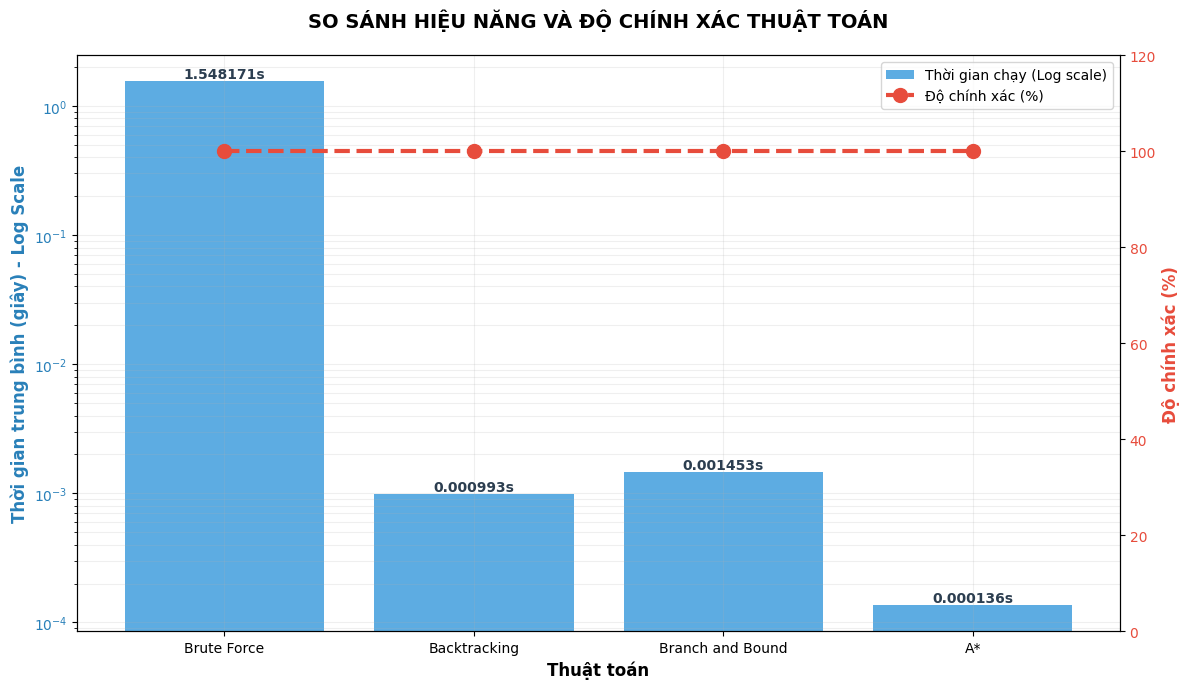

In [134]:
random.seed(42)
graphs_to_test = []
for _ in range(10):
    graphrd = generate_random_graph(15)
    graphs_to_test.append(graphrd)

results_stats = run_benchmark(graphs_to_test)
print(results_stats)
visualize_results_v2(results_stats)

Chạy với số đỉnh là 15 Vét cạn lớn gấp nhiều lần so với các thuật toán còn lại, nhánh cận chưa thể hiện được sự cắt nhánh

{'Brute Force': {'times': [inf, inf, inf, inf, inf, inf, inf, inf, inf, inf], 'costs': [inf, inf, inf, inf, inf, inf, inf, inf, inf, inf], 'optimal_cost': []}, 'Backtracking': {'times': [0.2004659999947762, 0.09065989998634905, 0.1317770999885397, 0.10137060000852216, 0.3965601000090828, 0.045633399990038015, 0.11213690000295173, 0.12313099998573307, 0.08216160000301898, 0.0491296000109287], 'costs': [446, 405, 183, 324, 275, 263, 144, 425, 382, 189], 'optimal_cost': []}, 'Branch and Bound': {'times': [0.060718499997165054, 0.02176570000301581, 0.0753392999904463, 0.030276300007244572, 0.16394430000218563, 0.02621309999085497, 0.05063049998716451, 0.05771490000188351, 0.07099870000092778, 0.0375960999954259], 'costs': [446, 405, 183, 324, 275, 263, 144, 425, 382, 189], 'optimal_cost': []}, 'A*': {'times': [0.0008595999970566481, 0.0005717000021832064, 0.0022316999966278672, 0.0005892000044696033, 0.0006074999982956797, 0.000509100005729124, 0.0005405999982031062, 0.001039199996739626, 

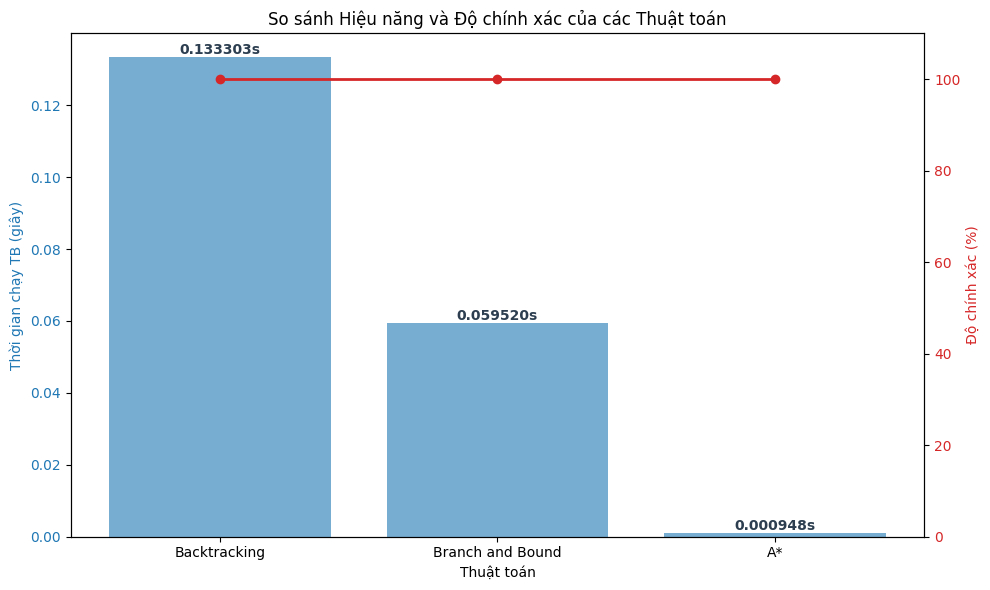

In [135]:
graphs_to_test = []
for _ in range(10):
    graphrd = generate_random_graph(50)
    graphs_to_test.append(graphrd)

results_stats = run_benchmark(graphs_to_test)
print(results_stats)
results_stats.pop("Brute Force") # Loại bỏ Brute Force do không thực thi được
analyze_and_plot(results_stats)

Chạy với 50 đỉnh, Nhánh cận thể hiện tốt hơn nhiều so với quay lui, A* thể thể hiện tốt nhất